# Method1: Nested cross validation

## 1. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine Learning
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# Tuning
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report, make_scorer

# Annotation
import shap
import mygene
import gseapy as gp

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 2. Load and Prepare Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Training_set_new_final.xlsx to Training_set_new_final.xlsx


### Quick Inspection

In [ ]:
X = pd.read_excel("Training_set_new_final.xlsx")
print(X.head())
y = X.pop('resp.pCR')
# Count class abundances
print(y.value_counts())

  Donor.ID  resp.pCR  RCB.score RCB.category  Age  T.stage  \
0     T001         0      0.980        RCB-I   51        2   
1     T002         1      0.000          pCR   42        4   
2     T003         1      0.000          pCR   36        2   
3     T004         0      2.075       RCB-II   33        3   
4     T005         0      2.866       RCB-II   49        3   

   LN.status.at.diagnosis  Histology  ER.status  HER2.status  ...  \
0                       0          1          1            1  ...   
1                       1          1          1            0  ...   
2                       0          1          1            1  ...   
3                       0          1          1            0  ...   
4                       1          1          1            0  ...   

   ENSG00000005421  Coding.TMB  CodingMuts.PIK3CA  CodingMuts.TP53  \
0         4.171345         118                  0                1   
1         5.722422          94                  0                0   
2 

### Load and Clean Data Function

In [ ]:
def load_data(path):

  """
    Load and clean clinical data from an Excel file, removing incomplete cases, and split into features and target.

    Parameters
    ----------
    path : str
        File path to the Excel workbook containing the dataset.

    Returns
    -------
    X : pandas.DataFrame
        Cleaned DataFrame of predictor features (excluding identifiers and target columns).
    y : pandas.Series
        Target variable series ('resp.pCR').

    """
  # 1) Read input data
  df = pd.read_excel(path)
  # 2) remove patients with any missing in features or target:
  df = df.dropna(subset=['resp.pCR']) # ensure target is present
  df = df.dropna(axis=0, how='any')   # remove any other missing

  # 3) Define columns to exclude from features
  exclude_cols = [
    'Donor.ID',   # unique patient identifier, not predictive
    'resp.pCR',   # the target variable
    'RCB.score',
    'RCB.category'
    ]

  # 4) Split into features X and target y
  X = df.drop(columns=exclude_cols)
  y = df['resp.pCR']
  return X, y

### Inspect Data After Cleaning

resp.pCR
0    109
1     39
Name: count, dtype: int64


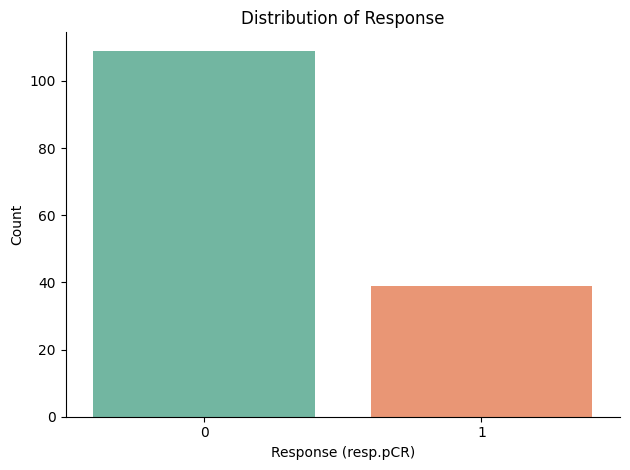

In [ ]:
X,y = load_data("Training_set_new_final.xlsx")
print(y.value_counts())

sns.countplot(x=y, palette=['#66c2a5', '#fc8d62'])    # or sns.countplot(y=y) for horizontal
plt.xlabel('Response (resp.pCR)')
plt.ylabel('Count')
plt.title('Distribution of Response')
sns.despine()         # optional: cleaner style
plt.tight_layout()
plt.show()

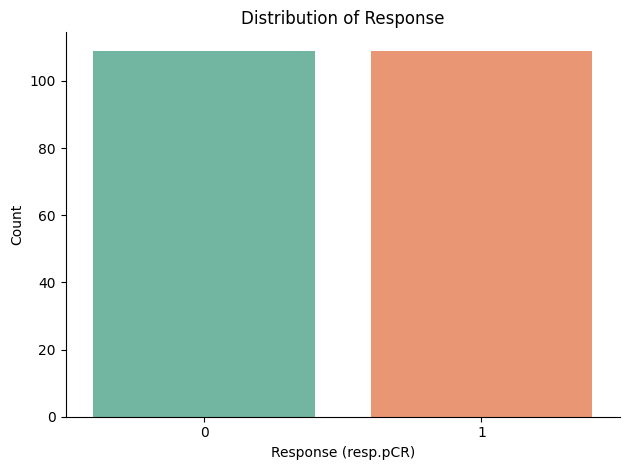

In [ ]:
# set random_state for reproducibility
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

sns.countplot(x=y_resampled, palette=['#66c2a5', '#fc8d62'])    # or sns.countplot(y=y) for horizontal
plt.xlabel('Response (resp.pCR)')
plt.ylabel('Count')
plt.title('Distribution of Response')
sns.despine()         # optional: cleaner style
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [ ]:
def build_preprocessor(feature_list):
  """
    Create a preprocessing transformer that standardizes specified features.

    Parameters
    ----------
    feature_list : list of str
        List of column names to be scaled (zero mean, unit variance).

    Returns
    -------
    ColumnTransformer
        A transformer that applies StandardScaler to the given feature_list.

    """
  return ColumnTransformer(
      transformers=[
          ('scale', StandardScaler(), feature_list)
          ])

### Feature Selection Transformers

In [ ]:
# Feature selection class
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.base import TransformerMixin

# (Optional) Custom transformer to drop highly‐correlated columns
class CorrelationFilter(TransformerMixin):

  """
    Transformer to drop one of each pair of highly correlated features.

    Parameters
    ----------
    threshold : float
        Absolute correlation value above which one of the pair is dropped.
  """

  def __init__(self, threshold=0.9):
    self.threshold = threshold

  def fit(self, X, y=None):
      corr = np.abs(np.corrcoef(X, rowvar=False))
      # find pairs above threshold
      to_drop = set()
      for i in range(corr.shape[0]):
          for j in range(i):
              if corr[i, j] > self.threshold:
                  to_drop.add(i)
      self.keep_idx_ = [i for i in range(X.shape[1]) if i not in to_drop]
      return self

  def transform(self, X):
      return X[:, self.keep_idx_]

## 4. Model Training and Evaluation (Nested CV)

### Nested Cross-Validation with Feature Selection Function

In [ ]:
def nested_cv_with_feature_selection(model, param_grid, X, y, name="Model"):

  """
    Perform nested cross-validation with feature selection steps:
      1) Preprocessing (scaling)
      2) VarianceThreshold to drop near-constant features
      3) CorrelationFilter to drop highly correlated features
      4) SelectKBest to choose top univariate features
      5) SMOTE for class balancing
      6) Classifier model

    Hyperparameters (including 'kbest__k') are tuned in the inner loop;
    metrics are evaluated in the outer loop.
  """

  feature_list = X.columns.tolist()
  preprocessor = build_preprocessor(feature_list)

  pipeline = ImbPipeline([
      ('pre',   preprocessor),
      # 1) drop near‐constant features first
      ('var',   VarianceThreshold(threshold=0.0)),
      # 2) drop highly‐correlated columns
      ('corr',  CorrelationFilter(threshold=0.9)),
      # 3) pick the K best univariate features
      ('kbest', SelectKBest(score_func=f_classif)),
      ('smote', SMOTE(random_state=42)),
      ('clf',   model)
    ])

  # tune both your model *and* the K in SelectKBest
  grid = GridSearchCV(
      pipeline,
      param_grid={
        **param_grid,
        'kbest__k': [10, 20, 30, 40, 45]       # try different numbers of features
      },
      cv=StratifiedKFold(5, shuffle=True, random_state=42),
      scoring='roc_auc',
      n_jobs=-1,
      refit=True
    )
  scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
  outer_cv = StratifiedKFold(5, shuffle=True, random_state=42)
  cv_results = cross_validate(
      grid, X, y,
      cv=outer_cv,
      scoring=scoring,
      n_jobs=-1
  )
  # 4) Aggregate mean scores
  mean_scores = {metric: cv_results[f'test_{metric}'].mean() for metric in scoring}

  # 5) Print & return
  print(f"\n--- {name} Nested CV ---")
  for metric, score in mean_scores.items():
    print(f"Mean {metric.capitalize():<9}: {score:.3f}")
  return mean_scores

### Model Tuning Function

In [ ]:
def tune_model(X, y, model, param_grid, name="Model"):
  # Build the preprocessor based on the columns of X before any preprocessing
  feature_list = X.columns.tolist()
  preprocessor = build_preprocessor(feature_list)

  # Create an imblearn pipeline that includes preprocessing, SMOTE, and the model
  # SMOTE should be applied after preprocessing but before the classifier
  pipeline = ImbPipeline([
      ('pre',   preprocessor),
      # 1) drop near‐constant features first
      ('var',   VarianceThreshold(threshold=0.0)),
      # 2) drop highly‐correlated columns
      ('corr',  CorrelationFilter(threshold=0.9)),
      # 3) pick the K best univariate features
      ('kbest', SelectKBest(score_func=f_classif)),
      ('smote', SMOTE(random_state=42)),
      ('clf',   model)
    ])

  # tune both your model *and* the K in SelectKBest
  grid = GridSearchCV(
      pipeline,
      param_grid={
        **param_grid,
        'kbest__k': [10, 20, 30, 40, 45]       # try different numbers of features
      },
      cv=StratifiedKFold(5, shuffle=True, random_state=42),
      scoring='roc_auc',
      n_jobs=-1,
      refit=True
    )

  grid.fit(X, y)
  best_model = grid.best_estimator_

  print(f"{name} Best AUC: {grid.best_score_:.3f}")
  return best_model

### Model Comparison and Visualization

Tuning LogisticRegression...

--- LogisticRegression Nested CV ---
Mean Roc_auc  : 0.987
Mean Accuracy : 0.946
Mean Precision: 0.873
Mean Recall   : 0.950
Mean F1       : 0.902
Tuning SVM...

--- SVM Nested CV ---
Mean Roc_auc  : 0.983
Mean Accuracy : 0.919
Mean Precision: 0.876
Mean Recall   : 0.825
Mean F1       : 0.839
Tuning RandomForest...

--- RandomForest Nested CV ---
Mean Roc_auc  : 0.917
Mean Accuracy : 0.845
Mean Precision: 0.710
Mean Recall   : 0.721
Mean F1       : 0.707
Tuning GradientBoosting...

--- GradientBoosting Nested CV ---
Mean Roc_auc  : 0.885
Mean Accuracy : 0.824
Mean Precision: 0.684
Mean Recall   : 0.639
Mean F1       : 0.652


,roc_auc,accuracy,precision,recall,f1
LogisticRegression,0.987013,0.945977,0.872778,0.950000,0.901886
SVM,0.982792,0.919080,0.876190,0.825000,0.839426
RandomForest,0.917478,0.844828,0.710000,0.721429,0.706606
GradientBoosting,0.885227,0.824138,0.683571,0.639286,0.652363


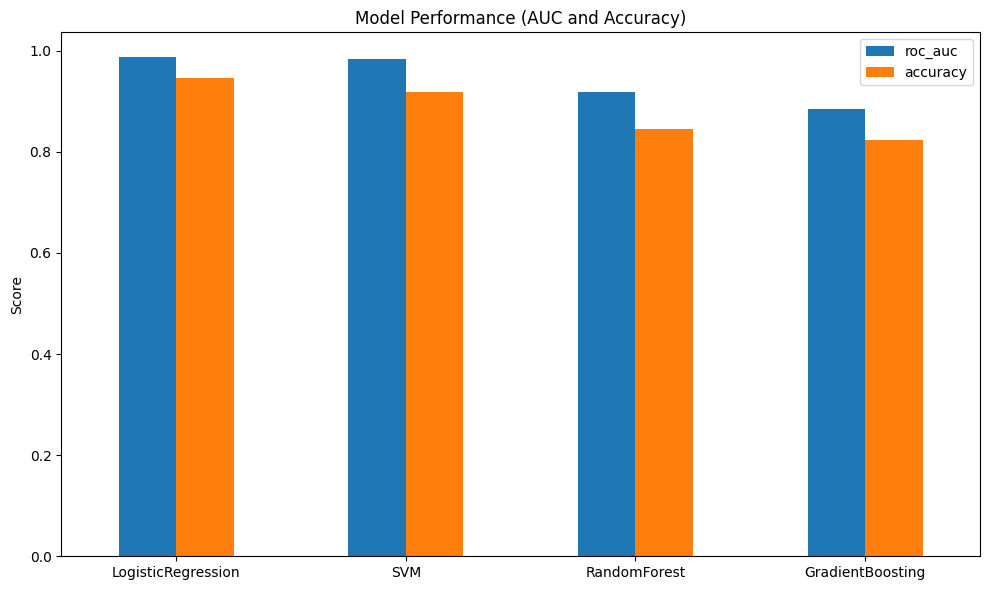

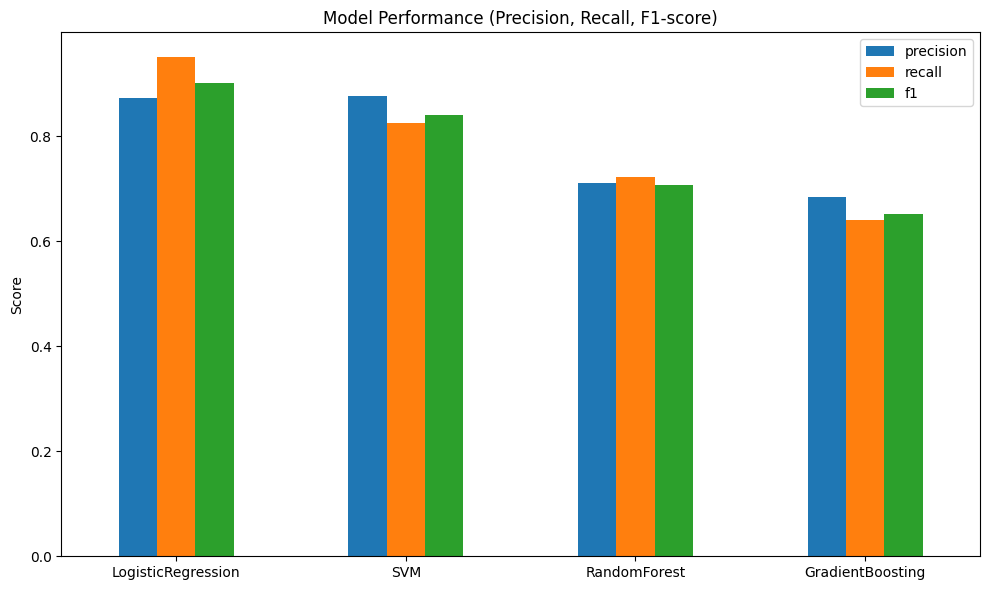

In [ ]:
if __name__ == "__main__":
  # Load the original data
    X_original, y = load_data("Training_set_new_final.xlsx")

    models = {
        "LogisticRegression": (LogisticRegression(max_iter=1000),
                               {"clf__C": [0.01, 0.1, 1, 10]}),
        "SVM": (SVC(probability=True),
                {"clf__C": [0.1, 1, 10], "clf__kernel": ["linear", "rbf"]}),
        "RandomForest": (RandomForestClassifier(),
                         {"clf__n_estimators": [100, 200], "clf__max_depth": [3, 5, None]}),
        "GradientBoosting": (GradientBoostingClassifier(),
                             {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.01, 0.1, 0.2]})
    }

    results = {}
    for name, (model, params) in models.items():
        print(f"Tuning {name}...")
        results[name] = nested_cv_with_feature_selection(model, params, X_original, y, name)

    # Visualize results
    metrics_df = pd.DataFrame(results).T
    display(metrics_df)

    metrics_df[['roc_auc', 'accuracy']].plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance (AUC and Accuracy)')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

    metrics_df[['precision', 'recall', 'f1']].plot(kind='bar', figsize=(10, 6))
    plt.title('Model Performance (Precision, Recall, F1-score)')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

### Confusion Matrices from Nested CV Predictions


--- LogisticRegression via nested CV predictions ---


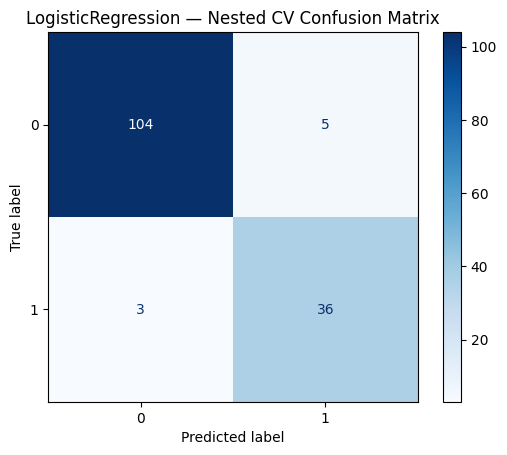


--- SVM via nested CV predictions ---


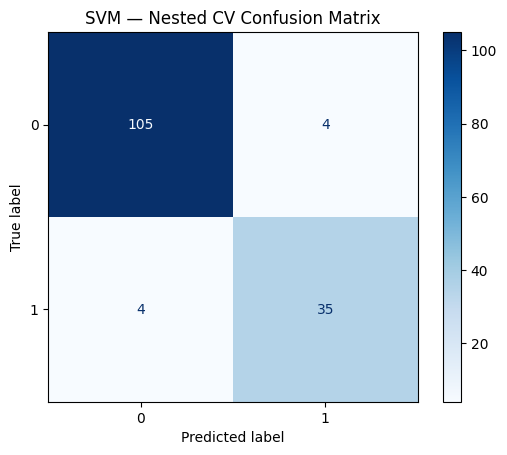


--- RandomForest via nested CV predictions ---


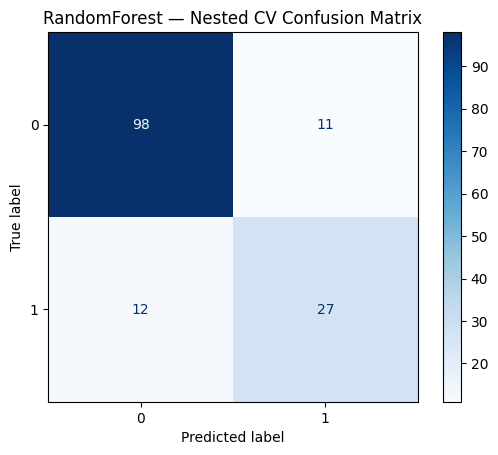


--- GradientBoosting via nested CV predictions ---


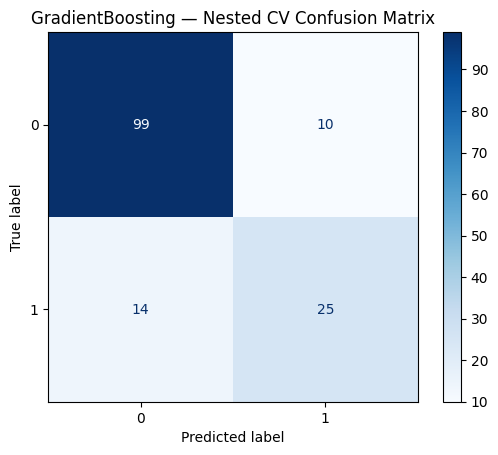

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, param_grid) in models.items():
    print(f"\n--- {name} via nested CV predictions ---")

    # 1) Build your pipeline (preprocessing + SMOTE + classifier)
    preprocessor = build_preprocessor(X_original.columns.tolist())
    pipeline = ImbPipeline([
        ('pre',   preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf',   model)
    ])

    # 2) Wrap in a GridSearch for inner‐loop tuning
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )

    # 3) Get *out-of-fold* predictions (the model is tuned *inside* each fold)
    y_pred_oof = cross_val_predict(
        grid,
        X_original, y,
        cv=outer_cv,
        n_jobs=-1,
        method='predict'
    )

    # 4) Build and plot the confusion matrix
    cm = confusion_matrix(y, y_pred_oof)
    disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
    disp.plot(cmap="Blues")
    plt.title(f'{name} — Nested CV Confusion Matrix')
    plt.show()

## 5. Model Interpretation (SHAP)

### SHAP Analysis for Logistic Regression

LogisticRegression Best AUC: 0.988
Calculating SHAP values...
Generating SHAP plots...


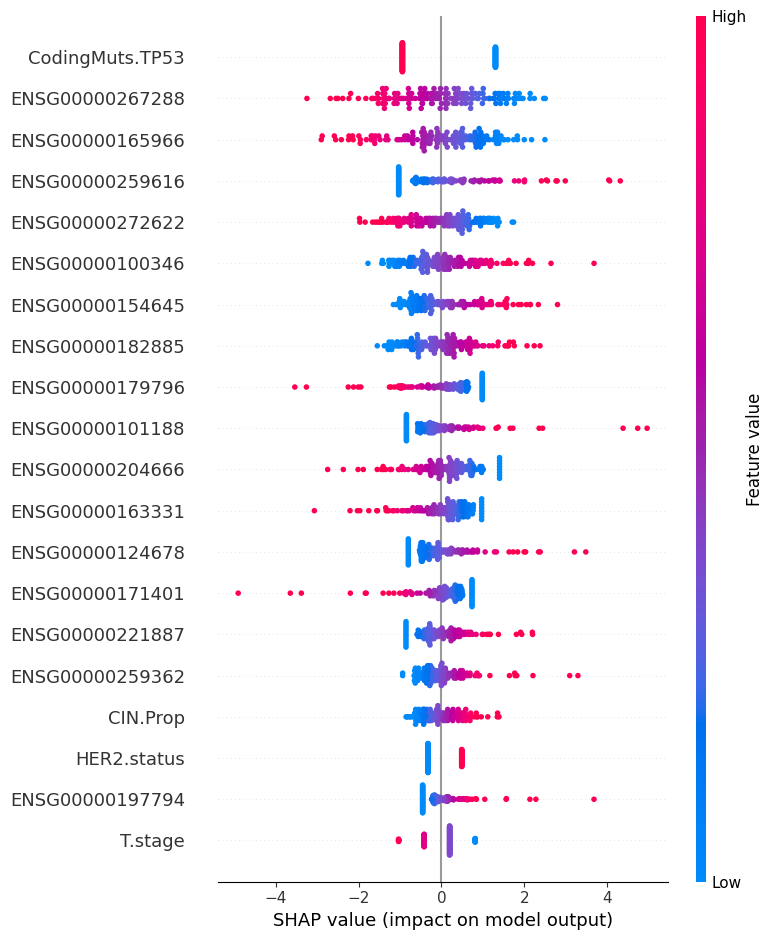

In [ ]:
# Tune only LogisticRegression and get back the fitted pipeline
best_pipeline = tune_model(
    X_original, y,
    LogisticRegression(max_iter=1000),
    {'clf__C': [0.01, 0.1, 1, 10]},
    name="LogisticRegression"
)

if best_pipeline is not None:
    #preprocessor = best_pipeline.named_steps['pre']
    classifier   = best_pipeline.named_steps['clf']

    transform_steps = [
    ('pre',   best_pipeline.named_steps['pre']),
    ('var',   best_pipeline.named_steps['var']),
    ('corr',  best_pipeline.named_steps['corr']),
    ('kbest', best_pipeline.named_steps['kbest']),
    ]
    feature_pipeline = Pipeline(transform_steps)
    X_processed = feature_pipeline.transform(X_original)

    # Apply preprocessing to the original data
    #preprocessor.fit(X_original)
    # X_processed = preprocessor.transform(X_original)

    # 5) Get feature names after ColumnTransformer
try:
    # scikit-learn ≥1.0
    feature_names = best_pipeline.named_steps['pre'].get_feature_names_out(
        input_features=X_original.columns.tolist()
    )
    raw_names = [fn.split("__", 1)[1] for fn in best_pipeline.named_steps['pre'].get_feature_names_out(
    input_features=X_original.columns.tolist()
    )]
except AttributeError:
    # fallback: build a dummy-encoded DataFrame
    filled = X_original.fillna(X_original.median(numeric_only=True))
    dummies = pd.get_dummies(filled, drop_first=True)
    feature_names = dummies.columns.tolist()
    raw_names = feature_names

# Use shap.Explainer
explainer = shap.Explainer(classifier, X_processed, feature_names=raw_names)

# Calculate SHAP values
print("Calculating SHAP values...")
shap_values = explainer(X_processed)

# Visualize SHAP results
print("Generating SHAP plots...")

# Summary plot
shap.summary_plot(shap_values, X_processed, feature_names=raw_names)

# Uncomment these lines to explore other SHAP plots:
# Dependence plot (example for the first feature)
# shap.dependence_plot(0, shap_values.values, X_processed, feature_names=feature_names)

# Force plot (for a single instance)
# shap.initjs()
# shap.force_plot(explainer.expected_value, shap_values.values[0,:], X_processed[0,:], feature_names=feature_names)

### SHAP Analysis for SVM



SVM Best AUC: 0.994
Calculating SHAP values for SVM...
Generating SHAP plots for SVM...


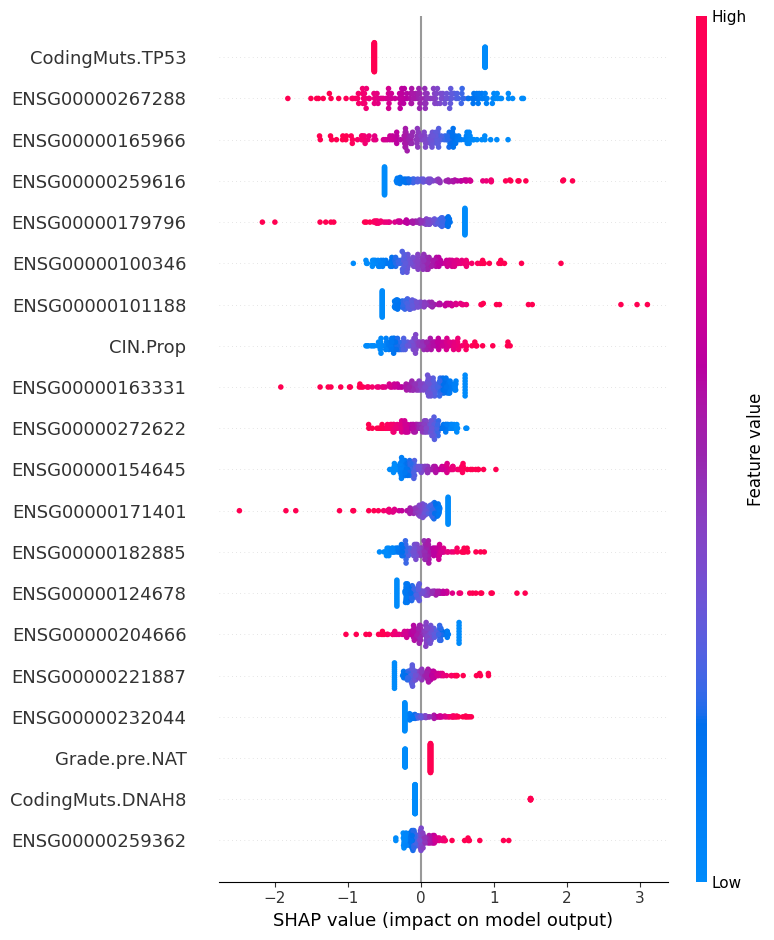

In [ ]:
# Tune SVM and get back the fitted pipeline
best_svm_pipeline = tune_model(
    X_original, y,
    SVC(probability=True),
    {"clf__C": [0.1, 1, 10], "clf__kernel": ["linear", "rbf"]},
    name="SVM"
)

if best_svm_pipeline is not None:
    classifier_svm   = best_svm_pipeline.named_steps['clf']

    transform_steps_svm = [
        ('pre',   best_svm_pipeline.named_steps['pre']),
        ('var',   best_svm_pipeline.named_steps['var']),
        ('corr',  best_svm_pipeline.named_steps['corr']),
        ('kbest', best_svm_pipeline.named_steps['kbest']),
    ]
    feature_pipeline_svm = Pipeline(transform_steps_svm)
    X_processed_svm = feature_pipeline_svm.transform(X_original)

    # Get feature names after ColumnTransformer
    try:
        # scikit-learn ≥1.0
        feature_names_svm = best_svm_pipeline.named_steps['pre'].get_feature_names_out(
            input_features=X_original.columns.tolist()
        )
        raw_names_svm = [fn.split("__", 1)[1] for fn in best_svm_pipeline.named_steps['pre'].get_feature_names_out(
            input_features=X_original.columns.tolist()
        )]
    except AttributeError:
        # fallback: build a dummy-encoded DataFrame
        filled = X_original.fillna(X_original.median(numeric_only=True))
        dummies = pd.get_dummies(filled, drop_first=True)
        feature_names_svm = dummies.columns.tolist()
        raw_names_svm = feature_names_svm

    # Use shap.Explainer
    explainer_svm = shap.Explainer(classifier_svm, X_processed_svm, feature_names=raw_names_svm)

    # Calculate SHAP values
    print("Calculating SHAP values for SVM...")
    shap_values_svm = explainer_svm(X_processed_svm)

    # Visualize SHAP results
    print("Generating SHAP plots for SVM...")

    # Summary plot
    shap.summary_plot(shap_values_svm, X_processed_svm, feature_names=raw_names_svm)

## 6. Biological Annotation

In [ ]:
# important features
ensembl_ids = [
    "ENSG00000259616", "ENSG00000165966", "ENSG00000267288",
    "ENSG00000179796", "ENSG00000100346", "ENSG00000101188",
    "ENSG00000163331", "ENSG00000272622"
]

# Initialize the mygene annotator
mg = mygene.MyGeneInfo()

# Query annotation information
annotations = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol,name', species='human')

# Convert to a DataFrame and extract the fields of interest
df = pd.DataFrame(annotations)[['query', 'symbol', 'name']]
df.columns = ['Ensembl_ID', 'Gene_Symbol', 'Description']

# Print or save the results
print(df)
# df.to_csv("gene_annotations.csv", index=False)

INFO:biothings.client:querying 1-8 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


        Ensembl_ID Gene_Symbol                                     Description
0  ENSG00000259616         NaN                                             NaN
1  ENSG00000165966      PDZRN4             PDZ domain containing ring finger 4
2  ENSG00000267288  HEXIM2-AS2                          HEXIM2 antisense RNA 2
3  ENSG00000179796      LRRC3B               leucine rich repeat containing 3B
4  ENSG00000100346     CACNA1I  calcium voltage-gated channel subunit alpha1 I
5  ENSG00000101188       NTSR1                          neurotensin receptor 1
6  ENSG00000163331       DAPL1                 death associated protein like 1
7  ENSG00000272622         NaN                                             NaN


In [ ]:
def annotate_ensembl_ids(
    ensembl_ids,
    fields=('symbol', 'name'),
    species='human',
    write_csv: str = None
) -> pd.DataFrame:
    """
    Query MyGene.info to map Ensembl Gene IDs to gene symbols and descriptions.

    Parameters
    ----------
    ensembl_ids : list of str
        List of Ensembl gene IDs (e.g. "ENSG00000141510").
    fields : tuple of str, optional
        Which fields to fetch from MyGene.info (default: ("symbol","name")).
    species : str, optional
        Species name for the query (default: "human").
    write_csv : str or None, optional
        If provided, path to write the resulting DataFrame as CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
          - Ensembl_ID
          - one column per field you requested (e.g. Gene_Symbol, Description)
    """
    # initialize client
    mg = mygene.MyGeneInfo()

    # query
    annotations = mg.querymany(
        ensembl_ids,
        scopes='ensembl.gene',
        fields=','.join(fields),
        species=species
    )

    # build DataFrame
    df = pd.DataFrame(annotations)

    # ensure requested fields exist, fill missing
    for f in fields:
        if f not in df.columns:
            df[f] = pd.NA

    # select and rename
    cols = ['query'] + list(fields)
    df = df[cols].copy()
    df.columns = ['Ensembl_ID'] + [f if f!='symbol' else 'Gene_Symbol'
                                   for f in fields]
    df.columns = [
        col if col!='name' else 'Description'
        for col in df.columns
    ]

    # optional CSV export
    if write_csv:
        df.to_csv(write_csv, index=False)

    return df

# Usage example
# Common features highlighted by both SVM and LR
ensembl_ids_common = [
    "ENSG00000259616",
    "ENSG00000165966",
    "ENSG00000267288",
    "ENSG00000179796",
    "ENSG00000100346",
    "ENSG00000101188",
    "ENSG00000163331",
    "ENSG00000272622"
]
df_common = annotate_ensembl_ids(
    ensembl_ids_common,
    fields=('symbol','name'),
    species='human',
    # write_csv="gene_annotations_common.csv"
)
print(df_common)

# Features highlighted by LR
ensembl_ids_lr  = [
    "ENSG00000267288",
    "ENSG00000165966",
    "ENSG00000259616",
    "ENSG00000272622",
    "ENSG00000100346",
    "ENSG00000154645",
    "ENSG00000182885",
    "ENSG00000179796",
    "ENSG00000101188",
    "ENSG00000204666",
    "ENSG00000163331",
    "ENSG00000124678",
    "ENSG00000171401",
    "ENSG00000221887",
    "ENSG00000259362",
    "ENSG00000197794"
]
df_lr = annotate_ensembl_ids(
    ensembl_ids_lr,
    fields=('symbol','name'),
    species='human',
    # write_csv="gene_annotations_lr.csv"
)
print(df_lr)

# Features highlighted by SVM
ensembl_ids_svm = [
    "ENSG00000267288",
    "ENSG00000165966",
    "ENSG00000259616",
    "ENSG00000179796",
    "ENSG00000100346",
    "ENSG00000101188",
    "ENSG00000163331",
    "ENSG00000272622",
    "ENSG00000154645",
    "ENSG00000171401",
    "ENSG00000182885",
    "ENSG00000124678",
    "ENSG00000204666",
    "ENSG00000221887",
    "ENSG00000232044",
    "ENSG00000259362",
]
df_svm = annotate_ensembl_ids(
    ensembl_ids_svm,
    fields=('symbol','name'),
    species='human',
    # write_csv="gene_annotations_svm.csv"
)
print(df_svm)

INFO:biothings.client:querying 1-8 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-16 ...


        Ensembl_ID Gene_Symbol                                     Description
0  ENSG00000259616         NaN                                             NaN
1  ENSG00000165966      PDZRN4             PDZ domain containing ring finger 4
2  ENSG00000267288  HEXIM2-AS2                          HEXIM2 antisense RNA 2
3  ENSG00000179796      LRRC3B               leucine rich repeat containing 3B
4  ENSG00000100346     CACNA1I  calcium voltage-gated channel subunit alpha1 I
5  ENSG00000101188       NTSR1                          neurotensin receptor 1
6  ENSG00000163331       DAPL1                 death associated protein like 1
7  ENSG00000272622         NaN                                             NaN


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-16 ...


         Ensembl_ID   Gene_Symbol  \
0   ENSG00000267288    HEXIM2-AS2   
1   ENSG00000165966        PDZRN4   
2   ENSG00000259616           NaN   
3   ENSG00000272622           NaN   
4   ENSG00000100346       CACNA1I   
5   ENSG00000154645         CHODL   
6   ENSG00000182885        ADGRG3   
7   ENSG00000179796        LRRC3B   
8   ENSG00000101188         NTSR1   
9   ENSG00000204666      ZNF473CR   
10  ENSG00000163331         DAPL1   
11  ENSG00000124678         TCP11   
12  ENSG00000171401         KRT13   
13  ENSG00000221887          HMSD   
14  ENSG00000259362  LOC101929457   
15  ENSG00000197794       IGKV7-3   

                                          Description  
0                              HEXIM2 antisense RNA 2  
1                 PDZ domain containing ring finger 4  
2                                                 NaN  
3                                                 NaN  
4      calcium voltage-gated channel subunit alpha1 I  
5                                 

INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


         Ensembl_ID   Gene_Symbol  \
0   ENSG00000267288    HEXIM2-AS2   
1   ENSG00000165966        PDZRN4   
2   ENSG00000259616           NaN   
3   ENSG00000179796        LRRC3B   
4   ENSG00000100346       CACNA1I   
5   ENSG00000101188         NTSR1   
6   ENSG00000163331         DAPL1   
7   ENSG00000272622           NaN   
8   ENSG00000154645         CHODL   
9   ENSG00000171401         KRT13   
10  ENSG00000182885        ADGRG3   
11  ENSG00000124678         TCP11   
12  ENSG00000204666      ZNF473CR   
13  ENSG00000221887          HMSD   
14  ENSG00000232044         SILC1   
15  ENSG00000259362  LOC101929457   

                                          Description  
0                              HEXIM2 antisense RNA 2  
1                 PDZ domain containing ring finger 4  
2                                                 NaN  
3                   leucine rich repeat containing 3B  
4      calcium voltage-gated channel subunit alpha1 I  
5                              neu

### GO/KEGG enrichment analysis

In [ ]:
def enrich_from_raw_genes(
    genes_raw: list[str],
    extra_symbols: list[str]     = None,
    species: str                 = 'human',
    go_library: str              = 'GO_Biological_Process_2021',
    kegg_library: str            = 'KEGG_2021_Human',
    cutoff: float                = 0.05,
    outdir: str                  = None
):
    """
    1) Filters genes_raw for Ensembl IDs (ENSG…)
    2) Looks up their HGNC symbols via MyGene.info
    3) Optionally appends extra_symbols (e.g. ['TP53'])
    4) Runs Enrichr GO BP and KEGG enrichment

    Returns
    -------
    gene_symbols : list[str]
        Unique HGNC symbols ready for enrichment.
    go_res : gseapy.Enrichr
        The GO Biological Process enrichment result.
    kegg_res : gseapy.Enrichr
        The KEGG pathway enrichment result.
    """
    # 1) keep only Ensembl IDs
    ensembl_ids = [g for g in genes_raw if g.upper().startswith('ENSG')]

    # 2) map to HGNC symbols
    mg = mygene.MyGeneInfo()
    query_res = mg.querymany(
        ensembl_ids,
        scopes='ensembl.gene',
        fields='symbol',
        species=species
    )
    gene_symbols = [entry['symbol'] for entry in query_res if 'symbol' in entry]

    # 3) append any extras (e.g. TP53)
    if extra_symbols:
        gene_symbols.extend(extra_symbols)

    # dedupe
    gene_symbols = list(set(gene_symbols))

    # 4a) GO BP enrichment
    go_res = gp.enrichr(
        gene_list=gene_symbols,
        gene_sets=[go_library],
        organism='Human',
        outdir=outdir,
        cutoff=cutoff
    )

    # 4b) KEGG enrichment
    kegg_res = gp.enrichr(
        gene_list=gene_symbols,
        gene_sets=[kegg_library],
        organism='Human',
        outdir=outdir,
        cutoff=cutoff
    )

    return gene_symbols, go_res, kegg_res

def plot_enrich_bubble(enrich_results, title, top_n=20, size_scale=1200):
    """
    Create a bubble plot from Enrichr enrichment results.

    Parameters
    ----------
    enrich_results : gseapy.Enrichr
        Result object returned by gseapy.enrichr() function.
    title : str
        Title for the plot.
    top_n : int, optional
        Number of top enriched terms to display (default is 20).
    size_scale : float, optional
        Scaling factor for bubble sizes (default is 1200).
    """
    # 1. Extract results and sort by adjusted p-value (smallest first)
    df = enrich_results.results.copy()
    df = df.sort_values(by='Adjusted P-value', ascending=True).head(top_n)

    # 2. Compute GeneRatio from Overlap (e.g., "3/120" → 3/120 = 0.025)
    df['GeneRatio'] = df['Overlap'].str.split('/').apply(
        lambda x: int(x[0]) / int(x[1]) if isinstance(x, list) else np.nan
    )

    # 3. Reverse the DataFrame to show most significant terms at the top
    df = df.iloc[::-1]

    # 4. Create the bubble plot using matplotlib
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        x=df['GeneRatio'],                          # X-axis: gene ratio
        y=df['Term'],                               # Y-axis: enriched term name
        s=df['GeneRatio'] * size_scale,             # Bubble size
        c=-np.log10(df['Adjusted P-value']),        # Bubble color (log-scaled p-value)
        cmap='viridis',                             # Colormap
        alpha=0.8,
        edgecolors='k'                              # Black edges
    )

    # 5. Add labels and colorbar
    plt.xlabel('Gene Ratio')
    plt.title(title)
    cbar = plt.colorbar(scatter)
    cbar.set_label('-log10(Adjusted P-value)')

    plt.tight_layout()
    plt.show()

INFO:biothings.client:querying 1-8 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-16 ...


Final gene symbols for enrichment: ['HEXIM2-AS2', 'LRRC3B', 'CACNA1I', 'TP53', 'DAPL1', 'PDZRN4', 'NTSR1']

Top GO BP hits:
                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0       cellular response to starvation (GO:0009267)   2/158  0.001269   
1               bone marrow development (GO:0048539)     1/5  0.001749   
2       cellular response to antibiotic (GO:0071236)     1/5  0.001749   
3  regulation of thymocyte apoptotic process (GO:...     1/6  0.002098   
4  positive regulation of RNA polymerase II trans...     1/7  0.002448   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.031947            0                     0   50.864103   
1          0.031947            0                     0  832.875000   
2          0.031947   

INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Final gene symbols for enrichment: ['HEXIM2-AS2', 'TCP11', 'IGKV7-3', 'CHODL', 'LRRC3B', 'CACNA1I', 'ZNF473CR', 'TP53', 'DAPL1', 'PDZRN4', 'NTSR1', 'HMSD', 'ADGRG3', 'LOC101929457', 'KRT13']

Top GO BP hits:
                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0               bone marrow development (GO:0048539)     1/5  0.003745   
1         regulation of cell maturation (GO:1903429)     1/5  0.003745   
2  negative regulation of CREB transcription fact...     1/5  0.003745   
3       cellular response to antibiotic (GO:0071236)     1/5  0.003745   
4  regulation of thymocyte apoptotic process (GO:...     1/6  0.004492   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.072112            0                     0  356.803571   
1       

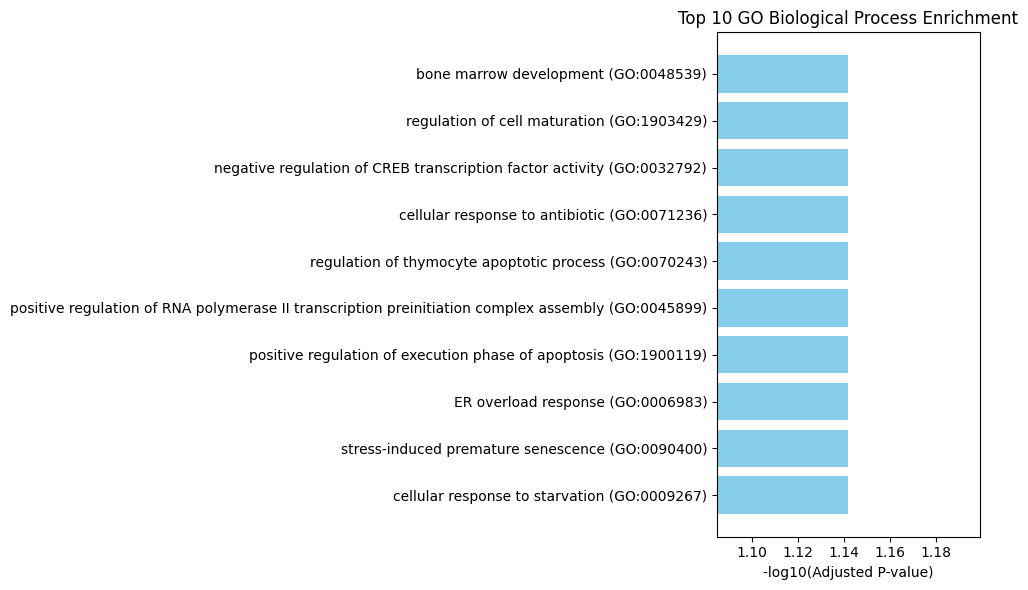

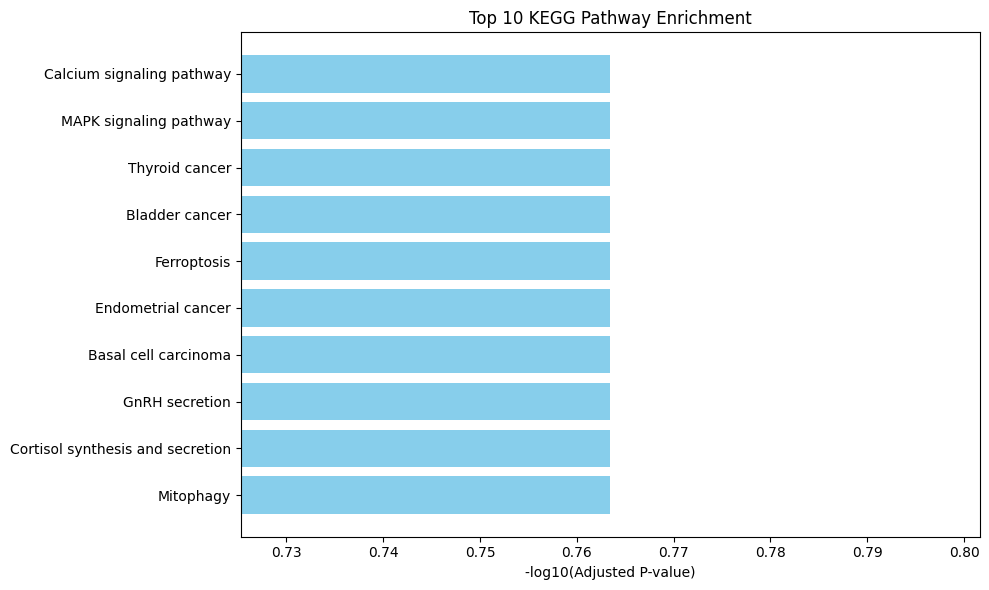

INFO:biothings.client:querying 1-16 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Final gene symbols for enrichment: ['HEXIM2-AS2', 'TCP11', 'CHODL', 'LRRC3B', 'CACNA1I', 'ZNF473CR', 'SILC1', 'TP53', 'DAPL1', 'PDZRN4', 'NTSR1', 'HMSD', 'ADGRG3', 'LOC101929457', 'KRT13']

Top GO BP hits:
                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0               bone marrow development (GO:0048539)     1/5  0.003745   
1         regulation of cell maturation (GO:1903429)     1/5  0.003745   
2  negative regulation of CREB transcription fact...     1/5  0.003745   
3       cellular response to antibiotic (GO:0071236)     1/5  0.003745   
4  regulation of thymocyte apoptotic process (GO:...     1/6  0.004492   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.072112            0                     0  356.803571   
1         

In [ ]:
ensembl_ids_common = [
    "ENSG00000259616",
    "ENSG00000165966",
    "ENSG00000267288",
    "ENSG00000179796",
    "ENSG00000100346",
    "ENSG00000101188",
    "ENSG00000163331",
    "ENSG00000272622"
]
# Call the function, telling it explicitly to include TP53
symbols_common, go_res_common, kegg_res_common = enrich_from_raw_genes(
    ensembl_ids_common,
    extra_symbols=['TP53']
)

print("Final gene symbols for enrichment:", symbols_common)
print("\nTop GO BP hits:")
print(go_res_common.results.head())

print("\nTop KEGG hits:")
print(kegg_res_common.results.head())

# Logistic Regression
ensembl_ids_lr  = [
    "ENSG00000267288",
    "ENSG00000165966",
    "ENSG00000259616",
    "ENSG00000272622",
    "ENSG00000100346",
    "ENSG00000154645",
    "ENSG00000182885",
    "ENSG00000179796",
    "ENSG00000101188",
    "ENSG00000204666",
    "ENSG00000163331",
    "ENSG00000124678",
    "ENSG00000171401",
    "ENSG00000221887",
    "ENSG00000259362",
    "ENSG00000197794"
]
# Call the function, telling it explicitly to include TP53
symbols_lr, go_res_lr, kegg_res_lr = enrich_from_raw_genes(
    ensembl_ids_lr,
    extra_symbols=['TP53']
)

print("Final gene symbols for enrichment:", symbols_lr)
print("\nTop GO BP hits:")
print(go_res_lr.results.head())

print("\nTop KEGG hits:")
print(kegg_res_lr.results.head())

# SVM
ensembl_ids_svm = [
    "ENSG00000267288",
    "ENSG00000165966",
    "ENSG00000259616",
    "ENSG00000179796",
    "ENSG00000100346",
    "ENSG00000101188",
    "ENSG00000163331",
    "ENSG00000272622",
    "ENSG00000154645",
    "ENSG00000171401",
    "ENSG00000182885",
    "ENSG00000124678",
    "ENSG00000204666",
    "ENSG00000221887",
    "ENSG00000232044",
    "ENSG00000259362",
]
# Call the function, telling it explicitly to include TP53
symbols_svm, go_res_svm, kegg_res_svm = enrich_from_raw_genes(
    ensembl_ids_svm,
    extra_symbols=['TP53']
)

print("Final gene symbols for enrichment:", symbols_svm)
print("\nTop GO BP hits:")
print(go_res_svm.results.head())

print("\nTop KEGG hits:")
print(kegg_res_svm.results.head())

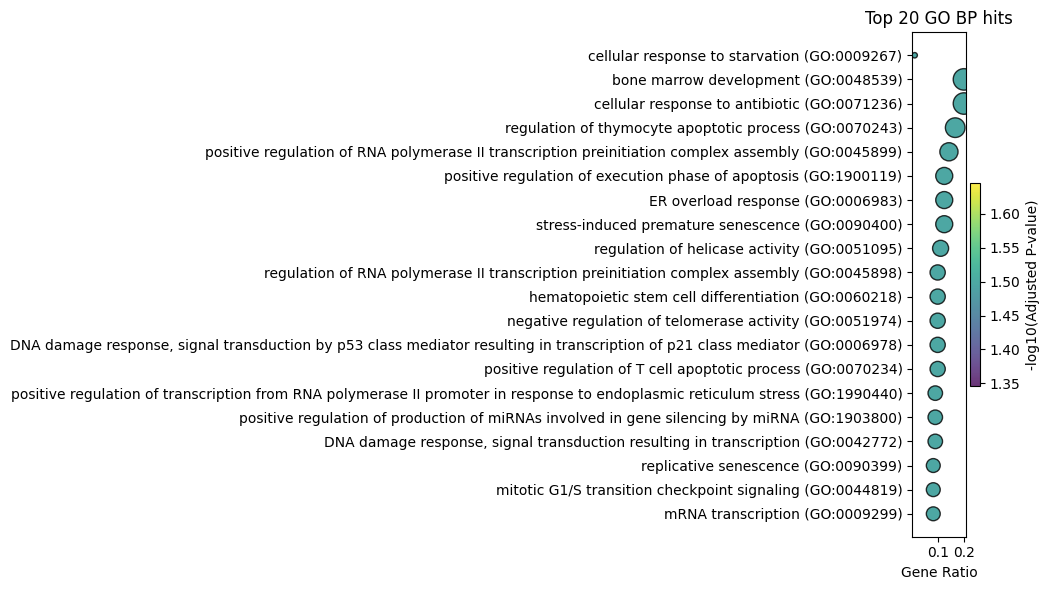

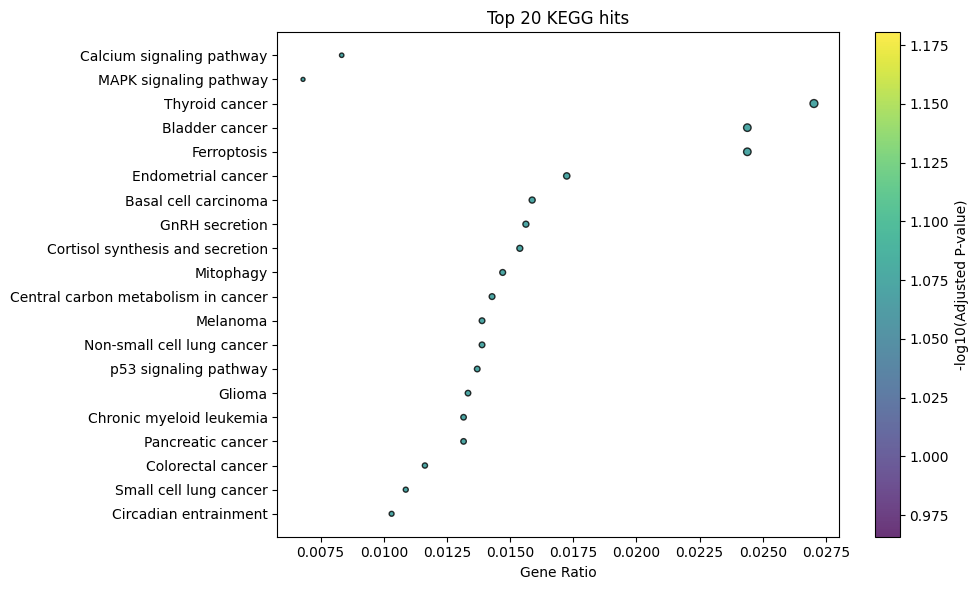

In [ ]:
# Plot bubble plots
# GO enrichment on common hits
plot_enrich_bubble(go_res_common, "Top 20 GO BP hits")
plot_enrich_bubble(kegg_res_common, "Top 20 KEGG hits")

INFO:biothings.client:querying 1-8 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Final gene symbols for enrichment: ['HEXIM2-AS2', 'LRRC3B', 'CACNA1I', 'TP53', 'DAPL1', 'PDZRN4', 'NTSR1']

Top GO Biological Process enrichment terms:
                     Gene_set  \
0  GO_Biological_Process_2021   
1  GO_Biological_Process_2021   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term Overlap   P-value  \
0       cellular response to starvation (GO:0009267)   2/158  0.001269   
1               bone marrow development (GO:0048539)     1/5  0.001749   
2       cellular response to antibiotic (GO:0071236)     1/5  0.001749   
3  regulation of thymocyte apoptotic process (GO:...     1/6  0.002098   
4  positive regulation of RNA polymerase II trans...     1/7  0.002448   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.031947            0                     0   50.864103   
1          0.031947            0                     0  832.8750

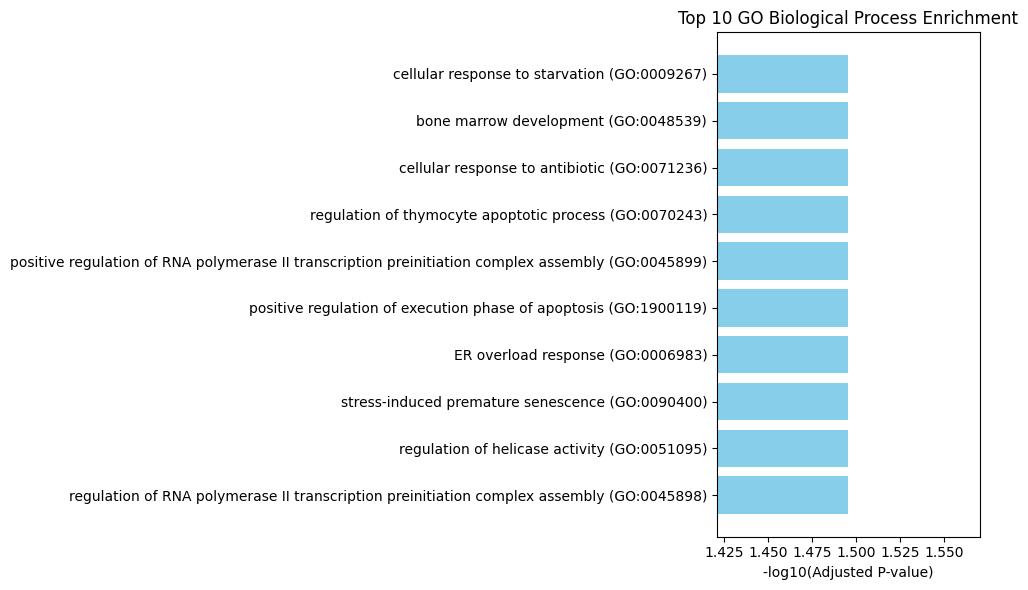

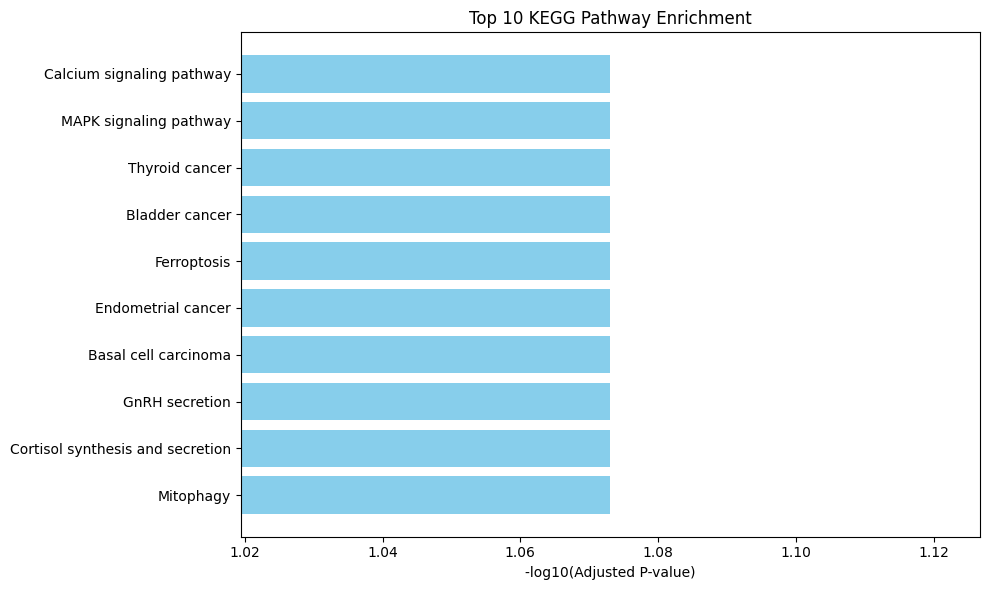

In [ ]:
# 1. Your gene list (mix of gene symbols and Ensembl IDs)
genes_raw = [
    "CodingMuts.TP53", "ENSG00000259616", "ENSG00000165966",
    "ENSG00000267288", "ENSG00000179796", "ENSG00000100346",
    "ENSG00000101188", "CIN.Prop", "ENSG00000163331", "ENSG00000272622"
]

# 2. Filter out non-Ensembl IDs (like CodingMuts.TP53 and CIN.Prop), keep only Ensembl IDs
ensembl_ids = [g for g in genes_raw if g.startswith("ENSG")]

# 3. Convert Ensembl IDs to gene symbols using mygene
mg = mygene.MyGeneInfo()
query_res = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

# Extract gene symbols, ignore entries without symbol field
gene_symbols = []
for entry in query_res:
    if 'symbol' in entry:
        gene_symbols.append(entry['symbol'])

# Add explicit TP53 gene symbol since it was in original list but not an Ensembl ID
gene_symbols.append("TP53")

# Remove duplicates
gene_symbols = list(set(gene_symbols))

print("Final gene symbols for enrichment:", gene_symbols)

# 4. Run GO Biological Process and KEGG pathway enrichment analysis with gseapy
go_res = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets=['GO_Biological_Process_2021'],
    organism='Human',
    outdir=None,  # Do not save to disk
    cutoff=0.05
)

kegg_res = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets=['KEGG_2021_Human'],
    organism='Human',
    outdir=None,
    cutoff=0.05
)

# 5. Print top enriched GO terms and KEGG pathways
print("\nTop GO Biological Process enrichment terms:")
print(go_res.results.head())

print("\nTop KEGG pathway enrichment terms:")
print(kegg_res.results.head())

# 6. Visualization function for enrichment results
def plot_enrich_results(enrich_results, title):
    df = enrich_results.results.head(10)
    df = df.sort_values(by='Adjusted P-value', ascending=True)
    plt.figure(figsize=(10,6))  # instead of (8,6)
    plt.barh(df['Term'], -np.log10(df['Adjusted P-value']), color='skyblue')
    plt.xlabel('-log10(Adjusted P-value)')
    plt.title(title)
    plt.gca().invert_yaxis()  # Show top terms on top

    # <<< Add these two lines to zoom in on the cluster of bar lengths:
    vals = -np.log10(df['Adjusted P-value'])
    plt.xlim(vals.min() * 0.95, vals.max() * 1.05)

    plt.tight_layout()
    plt.show()

# Plot top 10 GO BP terms and KEGG pathways
plot_enrich_results(go_res, "Top 10 GO Biological Process Enrichment")
plot_enrich_results(kegg_res, "Top 10 KEGG Pathway Enrichment")

GO Biological Process Enrichment：<br>
  TP53 is enriched in several critical processes:<br>
&emsp; Cellular response to starvation and response to antibiotic, suggesting roles in cellular stress responses.<br>
&emsp; Bone marrow development and regulation of thymocyte apoptosis, indicating involvement in immune and hematopoietic regulation.<br>
&emsp; Positive regulation of RNA polymerase II transcription, linking TP53 to transcriptional control.<br>
  DAPL1, together with TP53, appears in the “cellular response to starvation,” suggesting co-regulation of stress-related pathways.<br>
KEGG Pathway Enrichment:<br>
  TP53, CACNA1I, and NTSR1 are enriched in:<br>
&emsp; Calcium signaling and MAPK pathways, related to cell growth and stress signaling.<br>
&emsp; Thyroid cancer, bladder cancer, and ferroptosis, pointing to TP53’s central role in tumor biology and regulated cell death.<br>
These results highlight TP53 as a key regulatory hub, potentially influencing cancer progression and therapeutic response via multiple pathways.<br>


TP53, also known as tumor protein p53, is one of the most well-characterized tumor suppressor genes. It plays a central role in maintaining genomic stability by regulating key cellular processes, including cell cycle arrest, DNA repair, apoptosis, and senescence in response to various cellular stresses such as DNA damage and nutrient deprivation.<br>

In the context of our study on breast cancer neoadjuvant therapy response, TP53 mutations have been frequently observed and have been reported to influence treatment outcomes. Several studies suggest that TP53 mutation status is associated with chemotherapy sensitivity or resistance in breast cancer, particularly in triple-negative and HER2-positive subtypes.<br>

Our GO enrichment analysis shows that TP53 is significantly involved in “cellular response to starvation”, “response to antibiotic”, and “positive regulation of RNA polymerase II transcription”, indicating its role in stress response and transcriptional control under therapeutic pressure. Additionally, KEGG pathway enrichment revealed its involvement in MAPK signaling, calcium signaling, and ferroptosis, further supporting its role in cell fate decisions during treatment.<br>

These findings highlight TP53 as a potential key regulator in shaping therapy response through stress adaptation and cell death mechanisms. Further investigation into the interaction between TP53-mediated pathways and treatment response could help identify predictive biomarkers or novel therapeutic targets.<br>

1. Levine AJ. p53: 800 million years of evolution and 40 years of discovery. Nature Reviews Cancer. 2020.<br>
2. Bertheau P, et al. p53 in breast cancer subtypes: a complex marker and promising therapeutic target. World J Clin Oncol. 2012.<br>
3. Robson M, et al. Association of p53 Mutation with Sensitivity to Chemotherapy in Breast Cancer. JCO. 2011.<br>

# Method2: Train/Test split dataset
Compare the results of nested cross-validation with a 70/30 train/test split for model training and evaluation.

## 1. Split data

### Subtask:
Split the loaded and cleaned data into 70% training and 30% testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_original, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## 2. Modify tuning function

### Subtask:
Update the `tune_model` function to accept training and testing data separately.


In [ ]:
def tune_model(X_train, y_train, X_test, y_test, model, param_grid, name="Model"):
  # Build the preprocessor based on the columns of X before any preprocessing
  feature_list = X_train.columns.tolist()
  preprocessor = build_preprocessor(feature_list)

  # Create an imblearn pipeline that includes preprocessing, SMOTE, and the model
  # SMOTE should be applied after preprocessing but before the classifier
  pipeline = ImbPipeline([
      ('pre',   preprocessor),
      # 1) drop near‐constant features first
      ('var',   VarianceThreshold(threshold=0.0)),
      # 2) drop highly‐correlated columns
      ('corr',  CorrelationFilter(threshold=0.9)),
      # 3) pick the K best univariate features
      ('kbest', SelectKBest(score_func=f_classif)),
      ('smote', SMOTE(random_state=42)),
      ('clf',   model)
    ])

  # tune both your model *and* the K in SelectKBest
  grid = GridSearchCV(
      pipeline,
      param_grid={
        **param_grid,
        'kbest__k': [10, 20, 30, 40, 45]       # try different numbers of features
      },
      cv=StratifiedKFold(5, shuffle=True, random_state=42),
      scoring='roc_auc',
      n_jobs=-1,
      refit=True
    )

  grid.fit(X_train, y_train)
  best_model = grid.best_estimator_

  print(f"{name} Best AUC on training data during tuning: {grid.best_score_:.3f}")
  return best_model

## 3. Tune and train models

### Subtask:
Iterate through the models, tune them on the training data using the modified `tune_model` function.


In [ ]:
tuned_models = {}
for name, (model, params) in models.items():
    print(f"Tuning {name} on training data...")
    tuned_models[name] = tune_model(X_train, y_train, X_test, y_test, model, params, name)

## 4. Evaluate on test set

### Subtask:
Evaluate the performance of the best tuned model on the held-out test set using appropriate metrics.


In [ ]:
evaluation_results = {}

for name, pipeline in tuned_models.items():
    print(f"\nEvaluating {name} on the test set...")

    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

    # Calculate evaluation metrics
    roc_auc = roc_auc_score(y_test, y_proba)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the metrics
    evaluation_results[name] = {
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    # Print the metrics
    print(f"  ROC AUC  : {roc_auc:.3f}")
    print(f"  Accuracy : {accuracy:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall   : {recall:.3f}")
    print(f"  F1 Score : {f1:.3f}")


## 5. Compare results

### Subtask:
Compare the performance metrics obtained from the train/test split approach with the nested cross-validation results.


In [ ]:
# 1. Create DataFrame from evaluation_results (train/test split)
eval_df = pd.DataFrame(evaluation_results).T
# Add a column to identify the method
# eval_df['Method'] = 'Train/Test Split' # Removed as we are separating the tables

# 2. Create DataFrame from results (nested CV)
nested_cv_df = pd.DataFrame(results).T
# Add a column to identify the method
# nested_cv_df['Method'] = 'Nested CV' # Removed as we are separating the tables

# 3. Rename columns to indicate evaluation method (optional, can keep original names if preferred)
# eval_df.columns = [f'{col}' if col == 'Method' else f'{col}_train_test' for col in eval_df.columns] # Optional renaming
# nested_cv_df.columns = [f'{col}' if col == 'Method' else f'{col}_nested_cv' for col in nested_cv_df.columns] # Optional renaming


# 4. Display the two DataFrames separately
print("\n--- Nested Cross-Validation Results ---")
display(nested_cv_df)

print("--- Train/Test Split Results ---")
display(eval_df)

## 6. Summary

Here's a summary of the model performance using both Train/Test Split and Nested Cross-Validation:

**Observations:**

*   **Nested Cross-Validation** generally shows slightly higher performance metrics (AUC, Accuracy, Precision, Recall, F1) compared to the **Train/Test Split** for Logistic Regression and SVM. This is expected as nested CV provides a more robust estimate of model performance by averaging results across multiple train/validation/test splits.
*   **Logistic Regression and SVM** consistently perform better than Random Forest and Gradient Boosting across most metrics in both evaluation methods.
*   The differences in performance between the two methods are not drastic, which suggests that while nested CV provides a more reliable performance estimate, the train/test split also gives a reasonable indication of model performance on this dataset.

In conclusion, Logistic Regression and SVM appear to be the most promising models for this task, and nested cross-validation provides a more reliable assessment of their expected performance on unseen data.